exercise model
relationships found in:  all muscle tissue with no soleus    with P:0.15 S:2.5 allthr: 0.05
find best clusters in: all muscle tissue no soleus
overlap diff exp list from: all muscles including soleus
validate in indivudual tissues
validate in different muscle types
validate in humans 
test against: top 30 diff exp in all tissues

signature:
['Ldhb', 'Ttc9', 'Ankrd2', 'Atf3', 'Fabp3', 'Dusp18', 'Fxyd6', 'Myh1', 'Casq2', 'Slc26a10', 'Egln3', 'Myh2', 'BC048679', 'Gm5532', 'Fhl1', 'Actn2', 'Vgll2', 'Csrp3', 'Hspb7', 'Mb', 'Myom3', 'Lmcd1', 'Bdh1']
['H19', 'Ak4']
['Fbp2', 'Neu2', 'Fgfbp1', 'Pla2g5', 'Gstm2']

full clusters:
['Egln3', 'Mb', 'Vgll2', 'Bdh1', 'Dusp18', 'Myh1', 'Csrp3', 'Actn2', 'Idh2', 'Ldhb', 'Ankrd2', 'Gm5532', 'Fxyd6', 'Ppara', 'Lrrc52', 'Myom3', 'Fabp3-ps1', 'Slc25a34', 'Lmcd1', 'Myoz2', 'Hspb7', 'Myh2', 'Slc26a10', 'Fhl1', 'Abhd18', 'Ttc9', 'BC048679', 'Casq2', 'Gm15543', 'Dgat2', 'Fabp3', 'Atp1b1', 'Atf3']
['Cyfip2', 'H19', 'Lrfn4', 'Ak4']
['Ppp1r1a', 'Gm12514', 'Gstm2', 'Gm47708', 'Fbp2', 'Fgfbp1', 'Gm15337', 'Xist', 'Cdkn1a', 'Pla2g5', 'Aebp1', 'Kazald1', 'Stc2', 'Neu2']

In [1]:
import sys
sys.path.append("/booleanfs2/sahoo/Hegemon/")
sys.path = ["/booleanfs2/sahoo/BoNE/"] + sys.path

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

from matplotlib import pyplot as plt
import statistics
import os
class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

try:
    reload  # Python 2.7
except NameError:
    try:
        from importlib import reload  # Python 3.4+
    except ImportError:
        from imp import reload  # Python 3.0 - 3.3
        
import SMaRT.MacUtils as mut
reload(mut)

import bone
reload(bone)
pd = bone.pd
hu = bone.hu
np = bone.np

def plotTitleBar1(ana, ax=None, desc=None):
    acolor = ["#55a0fb","#f94040","cyan","pink"]
    expr = ana.f_ranks
    v1 = [expr[i-2] for i in ana.state[0]]
    v2 = [expr[i-2] for i in ana.state[1]]
    t, p = bone.ttest_ind(v1,v2, equal_var=False)
    expr = [expr[i-2] for i in ana.order]
    ana.cval = [[ana.aval[ana.order[i]] for i in bone.np.argsort(expr)]]
    ax = ana.printTitleBar({'w':4, 'h':0.5, 'spaceAnn': len(ana.order)/len(ana.atypes),
                            'tAnn': 1, 'widthAnn':1, 'ax':ax, 'acolor':acolor})
    if desc == None:
        desc = ana.h.getSource() + f"({len(ana.state[0])},{len(ana.state[1])})"
    ax.text(-1, 2, desc, horizontalalignment='right', verticalalignment='center')
    actual = ana.cval[0]
    score = [expr[i] for i in bone.np.argsort(expr)]
    fpr, tpr, thrs = bone.roc_curve(actual, score, pos_label=1)
    auc = bone.auc(fpr, tpr)
    roc_auc = "%.2f %.3g" % (auc, p)
    ax.text(len(ana.cval[0]), 2, roc_auc)
    return [auc]

def plotTitleBar(ana, ax=None, desc=None):
    acolor = ["#55a0fb","#f94040","cyan","pink"]
    expr = ana.f_ranks
    v1 = [expr[i-2] for i in ana.state[0]]
    v2 = [expr[i-2] for i in ana.state[1]]
    t, p = bone.ttest_ind(v1,v2, equal_var=False)
    expr = [expr[i-2] for i in ana.order]
    ana.cval = [[ana.aval[ana.order[i]] for i in bone.np.argsort(expr)]]
    ax = ana.printTitleBar({'w':4, 'h':0.5, 'spaceAnn': len(ana.order)/len(ana.atypes),
                            'tAnn': 1, 'widthAnn':1, 'ax':ax, 'acolor':acolor})
    if desc == None:
        desc = ana.h.getSource() + f"({len(ana.state[0])},{len(ana.state[1])})"
    #ax.text(-1, 2, desc, horizontalalignment='right', verticalalignment='center')
    actual = ana.cval[0]
    score = [expr[i] for i in bone.np.argsort(expr)]
    fpr, tpr, thrs = bone.roc_curve(actual, score, pos_label=1)
    auc = bone.auc(fpr, tpr)
    roc_auc = "%.2f %.3g" % (auc, p)
    ax.text(len(ana.cval[0]), 2, desc+" "+roc_auc)
    return [auc]


def getPanda2024Exercise(self, tn=1, ta=None, tb=None):
    self.prepareData("mmex1", "/Users/aglina/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c Group")
    atypes = ['Sed', 'RW']
    ahash = {}
    if tn == 2:
        tissue = self.h.getSurvName("c Tissue")
        atype = [atype[i] if tissue[i] == ta
                else None for i in range(len(atype))]
    if tn == 3:
        sex = self.h.getSurvName("c Sex")
        atype = [atype[i] if sex[i] == ta
                else None for i in range(len(atype))]
    if tn == 4:
        tissue = self.h.getSurvName("c Tissue")
        sex = self.h.getSurvName("c Sex")
        atype = [atype[i] if tissue[i] == ta and sex[i] == tb
                else None for i in range(len(atype))]
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getPanda2024Exercise = getPanda2024Exercise
def getPanda2024MuscleOnly(self, tn=1, ta=None):
    self.prepareData("mmex2", "/Users/aglina/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c Group")
    atypes = ['Sed', 'RW']
    ahash = {}
    if tn == 2:
        tissue = self.h.getSurvName("c Tissue")
        atype = [atype[i] if tissue[i] == ta
                else None for i in range(len(atype))]
    if tn==3:
        atype = self.h.getSurvName("c Group SolOrMuscle")
        atypes = ['Sed_oMuscle', 'RW_oMuscle',"Sed_Sol","RW_Sol"]
        ahash = {'Sed_oMuscle':0, 'RW_oMuscle':1,"Sed_Sol":2,"RW_Sol":3}    
    self.initData(atype, atypes, ahash)
    return
bone.IBDAnalysis.getPanda2024MuscleOnly = getPanda2024MuscleOnly

def getPanda2024MuscleOnlynoSol(self, tn=1, ta=None):
    self.prepareData("mmex3", "/Users/aglina/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c Group")
    atypes = ['Sed', 'RW']
    ahash = {}
    if tn == 2:
        tissue = self.h.getSurvName("c Tissue")
        atype = [atype[i] if tissue[i] == ta
                else None for i in range(len(atype))]
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getPanda2024MuscleOnlynoSol = getPanda2024MuscleOnlynoSol

def getDreher2023AccuteLongTermVLat(self, tn=0):
    self.prepareData("M83-1","/Users/aglina/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c time_point_ch1")
    if tn==0:
        atypes = ['BaselineComb', 'Post TrainingComb']
        ahash = {'Baseline':0, 'Post_Training':1,'Baseline_Acute':0, 'Post_Training_Acute':1}
    if tn==1:
        atypes = ['Baseline', 'Post Training']
        ahash = {'Baseline':0, 'Post_Training':1}
    if tn==2:
        atypes = ['Baseline Acute', 'Post Training Acute']
        ahash = {'Baseline_Acute':0, 'Post_Training_Acute':1}
    if tn==3:
        atypes = ['Baseline', 'Post Training', 'Baseline Acute','Post Training Acute']
        ahash = {'Baseline':0, 'Post_Training':1,'Baseline_Acute':2, 'Post_Training_Acute':3}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getDreher2023AccuteLongTermVLat = getDreher2023AccuteLongTermVLat
def getHansen2015(self, tn=1):
    self.prepareData("M44",'/Users/yovosko/public_html/Hegemon/explore.conf')
    if tn == 1:
        atype = self.h.getSurvName("c source_name (ch1)")
        atypes = ["diabetes","no diabetes"]
        ahash = {'Skeletal muscle biopsy, subject with normal glucose tolerance, before excercise':1,'Skeletal muscle biopsy, subject with normal glucose tolerance, after 60min excercise':1,'Skeletal muscle biopsy, subject with normal glucose tolerance, 3h after excercise':1,
                 'Skeletal muscle biopsy, subject with type 2 diabetes, before excercise':0,'Skeletal muscle biopsy, subject with type 2 diabetes, after 60min excercise':0,'Skeletal muscle biopsy, subject with type 2 diabetes, 3h after excercise':0} #removed '50-59':1
    if tn == 'ex':
        atype = self.h.getSurvName("c source_name (ch1)")
        atypes = ["pre ex","1h post ex","3hr post ex"]
        ahash = {'Skeletal muscle biopsy, subject with normal glucose tolerance, before excercise':0,'Skeletal muscle biopsy, subject with normal glucose tolerance, after 60min excercise':1,'Skeletal muscle biopsy, subject with normal glucose tolerance, 3h after excercise':2,
                 'Skeletal muscle biopsy, subject with type 2 diabetes, before excercise':0,'Skeletal muscle biopsy, subject with type 2 diabetes, after 60min excercise':1,'Skeletal muscle biopsy, subject with type 2 diabetes, 3h after excercise':2}
    if tn == 'all ex':
        atype = self.h.getSurvName("c source_name (ch1)")
        atypes = ["pre ex","post ex"]
        ahash = {'Skeletal muscle biopsy, subject with normal glucose tolerance, before excercise':0,'Skeletal muscle biopsy, subject with normal glucose tolerance, after 60min excercise':1,'Skeletal muscle biopsy, subject with normal glucose tolerance, 3h after excercise':1,
                 'Skeletal muscle biopsy, subject with type 2 diabetes, before excercise':0,'Skeletal muscle biopsy, subject with type 2 diabetes, after 60min excercise':1,'Skeletal muscle biopsy, subject with type 2 diabetes, 3h after excercise':1}
    if tn == '3hr ex':
        atype = self.h.getSurvName("c source_name (ch1)")
        atypes = ["pre ex","post ex"]
        ahash = {'Skeletal muscle biopsy, subject with normal glucose tolerance, before excercise':0,'Skeletal muscle biopsy, subject with normal glucose tolerance, 3h after excercise':1,
                 'Skeletal muscle biopsy, subject with type 2 diabetes, before excercise':0,'Skeletal muscle biopsy, subject with type 2 diabetes, 3h after excercise':1}
    if tn == '1hr ex':
        atype = self.h.getSurvName("c source_name (ch1)")
        atypes = ["pre ex","post ex"]
        ahash = {'Skeletal muscle biopsy, subject with normal glucose tolerance, before excercise':0,'Skeletal muscle biopsy, subject with normal glucose tolerance, after 60min excercise':1,
                 'Skeletal muscle biopsy, subject with type 2 diabetes, before excercise':0,'Skeletal muscle biopsy, subject with type 2 diabetes, after 60min excercise':1}
    if tn == "nodia":
        atype = self.h.getSurvName("c source_name (ch1)")
        atypes = ["pre ex","post ex"]
        ahash = {'Skeletal muscle biopsy, subject with normal glucose tolerance, before excercise':0,'Skeletal muscle biopsy, subject with normal glucose tolerance, after 60min excercise':1,'Skeletal muscle biopsy, subject with normal glucose tolerance, 3h after excercise':1}


    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getHansen2015 = getHansen2015
def getMotrpacVL(self, tn=0):
    self.prepareData("mtrpk17","/Users/aglina/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c study_group_timepoint")

    if tn==1:
        atypes = ['control', 'all trained']
        ahash = {'Control - 8 weeks':0, 'Training - 8 weeks':1,'Training - 4 weeks':1,'Training - 2 weeks':1,'Training - 1 week':1}
    if tn ==0:
        atypes = ['Control','Training - 1 weeks','Training - 2 weeks','Training - 4 weeks','Training - 8 weeks']
        ahash = {'Control - 8 weeks':0, 'Training - 1 week':1,'Training - 2 weeks':2,'Training - 4 weeks':3,'Training - 8 weeks':4}
    if tn ==11:
        atypes = ['Control','Training - 1 weeks']
        ahash = {'Control - 8 weeks':0, 'Training - 1 week':1}
    if tn==8:
        atypes = ['control', 'Training - 8 weeks']
        ahash = {'Control - 8 weeks':0, 'Training - 8 weeks':1}
    if tn==4:
        atypes = ['control', 'Training - 4 weeks']
        ahash = {'Control - 8 weeks':0, 'Training - 4 weeks':1}
    if tn==2:
        atypes = ['control', 'Training - 2 weeks']
        ahash = {'Control - 8 weeks':0, 'Training - 2 weeks':1}
    if tn==48:
        atypes = ['control', 'Training - 4 & 8 weeks']
        ahash = {'Control - 8 weeks':0, 'Training - 4 weeks':1, 'Training - 8 weeks':1}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getMotrpacVL = getMotrpacVL
def getMotrpacGas(self, tn=0):
    self.prepareData("mtrpk6","/Users/aglina/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c study_group_timepoint")
    if tn==1:
        atypes = ['control', 'all trained']
        ahash = {'Control - 8 weeks':0, 'Training - 8 weeks':1,'Training - 4 weeks':1,'Training - 2 weeks':1,'Training - 1 week':1}
    if tn ==0:
        atypes = ['Control','Training - 1 weeks','Training - 2 weeks','Training - 4 weeks','Training - 8 weeks']
        ahash = {'Control - 8 weeks':0, 'Training - 1 week':1,'Training - 2 weeks':2,'Training - 4 weeks':3,'Training - 8 weeks':4}
    if tn ==2:
        atypes = ['Control','Training - 1 weeks']
        ahash = {'Control - 8 weeks':0, 'Training - 1 week':1}
    if tn==8:
        atypes = ['control', 'Training - 8 weeks']
        ahash = {'Control - 8 weeks':0, 'Training - 8 weeks':1}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getMotrpacGas = getMotrpacGas

def getMacNeil2010(self, tn=0):
    self.prepareData("M55","/Users/yovosko/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c condition_ch1")
    atypes = ['Pre', 'Post']
    ahash = {'Pre':0, 'Post':1}
    self.initData(atype, atypes, ahash) 
    return
bone.IBDAnalysis.getMacNeil2010 = getMacNeil2010
def getRaue2012(self, tn=0):
    self.prepareData("M58","/Users/yovosko/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c time point_ch1")
    atypes = ['Pre', 'Post']
    ahash = {'Basal':0, '4hrs post exercise':1}
    self.initData(atype, atypes, ahash) 
    return
bone.IBDAnalysis.getRaue2012 = getRaue2012
def getSato2019(self, tn=0):
    self.prepareData("M87","/Users/yovosko/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c treatment_ch1")
    atypes = ['Sed', 'RW']
    ahash = {'Sedentary':0, 'Exercise':1}
    if tn =="active phase":
        atype = self.h.getSurvName("c treatment_phase")
        atypes = ['Sed', 'RW']
        ahash = {'Sedentary Active phase (ZT15)':0, 'Exercise Active phase (ZT15)':1}
    if tn =="rest phase":
        atype = self.h.getSurvName("c treatment_phase")
        atypes = ['Sed', 'RW']
        ahash = {'Sedentary Rest phase (ZT3)':0, 'Exercise Rest phase (ZT3)':1}
    self.initData(atype, atypes, ahash) 
    return
bone.IBDAnalysis.getSato2019 = getSato2019
def getSchjerling2014EnduranceOnly(self, tn=1, ta=0, tb=0):
    self.prepareData("M11",'/Users/yovosko/public_html/Hegemon/explore.conf')
    atype = self.h.getSurvName("c training type_ch1")
    atypes = ['Sed', 'Endurance Training']
    ahash = {'Control':0, 'Endurance':1}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getSchjerling2014EnduranceOnly = getSchjerling2014EnduranceOnly
def getSchjerling2014StrengthOnly(self, tn=1, ta=0, tb=0):
    self.prepareData("M11",'/Users/yovosko/public_html/Hegemon/explore.conf')
    atype = self.h.getSurvName("c training type_ch1")
    atypes = ['Sed', 'Strength Training']
    ahash = {'Control':0, 'Strength':1}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getSchjerling2014StrengthOnly = getSchjerling2014StrengthOnly
def getSchjerling2014(self, tn=1):
    self.prepareData("M11",'/Users/yovosko/public_html/Hegemon/explore.conf')
    atype = self.h.getSurvName("c training type_ch1")
    if tn==1:
        atypes = ['Sed', 'Exercise']
        ahash = {'Control':0, 'Endurance':1,'Strength':1}
    if tn==2:
        atypes = ['Sed', 'Endurance', 'Strength']
        ahash = {'Control':0, 'Endurance':1,'Strength':2}
    if tn==3:
        atypes = ['Endurance', 'Strength']
        ahash = {'Endurance':0,'Strength':1}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getSchjerling2014 = getSchjerling2014


def getMotrpacMuscle(self, tn=0):
    self.prepareData("mtrpk1","/Users/aglina/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c study_group_timepoint")

    if tn==1:
        atypes = ['control', 'all trained']
        ahash = {'Control - 8 weeks':0, 'Training - 8 weeks':1,'Training - 4 weeks':1,'Training - 2 weeks':1,'Training - 1 week':1}
    if tn ==0:
        atypes = ['Control','Training - 1 weeks','Training - 2 weeks','Training - 4 weeks','Training - 8 weeks']
        ahash = {'Control - 8 weeks':0, 'Training - 1 week':1,'Training - 2 weeks':2,'Training - 4 weeks':3,'Training - 8 weeks':4}
    if tn ==11:
        atypes = ['Control','Training - 1 weeks']
        ahash = {'Control - 8 weeks':0, 'Training - 1 week':1}
    if tn==8:
        atypes = ['control', 'Training - 8 weeks']
        ahash = {'Control - 8 weeks':0, 'Training - 8 weeks':1}
    if tn==4:
        atypes = ['control', 'Training - 4 weeks']
        ahash = {'Control - 8 weeks':0, 'Training - 4 weeks':1}
    if tn==2:
        atypes = ['control', 'Training - 2 weeks']
        ahash = {'Control - 8 weeks':0, 'Training - 2 weeks':1}
    if tn==48:
        atypes = ['control', 'Training - 4 & 8 weeks']
        ahash = {'Control - 8 weeks':0, 'Training - 4 weeks':1, 'Training - 8 weeks':1}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getMotrpacMuscle = getMotrpacMuscle

def getmoore2023mouse(self, tn=1, ta=0, tb=0):
    self.prepareData("M105-1","/Users/aglina/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c exercise group_ch1")
    atypes = ['Sedentary', 'Exercised']
    ahash = {'Sedentary':0, 'Exercised':1}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getmoore2023mouse = getmoore2023mouse
def getBohm2016(self, tn=1, ta=0, tb=0):
    self.prepareData("M52","/Users/yovosko/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c Time Point (ch1)")
    atypes = ['BeforeT', 'AfterT']
    ahash = {'Before Training':0, 'After Eight Weeks Endurance Training':1}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getBohm2016 = getBohm2016
import re
def getDeSanctis2021(self, tn=1,simpleNames=False):
    self.prepareData("M28","/Users/yovosko/public_html/Hegemon/explore.conf")
    if tn==1:
        atype = self.h.getSurvName("c group (ch1)")
        ahash = {'sedentary':0,'resistance trained':1,'endurance trained':1}
        atypes=['Sedentary','Athlete']
        if simpleNames:
            atypes=['Untrain','Train']
    if tn==2:
        atype = self.h.getSurvName("c group (ch1)")
        ahash = {'sedentary':0,'resistance trained':1,'endurance trained':2}
        atypes=['Sedentary','Resistance','Endurance']
    atype = [re.sub(".* in ", "", str(k)) for k in atype]
    self.initData(atype, atypes, ahash)
    return
bone.IBDAnalysis.getDeSanctis2021 = getDeSanctis2021

/booleanfs2/sahoo/BoNE/SMaRT/MacUtils.py:466: SyntaxWarning: invalid escape sequence '\s'
  ll = re.split("[\s]", line);
/booleanfs2/sahoo/BoNE/SMaRT/MacUtils.py:1002: SyntaxWarning: invalid escape sequence '\['
  nodelist = re.split("[\[\]()\s]", genes)
/booleanfs2/sahoo/BoNE/SMaRT/MacUtils.py:1005: SyntaxWarning: invalid escape sequence '\['
  ll = re.split("[\[\]()\s]", line);
/booleanfs2/sahoo/BoNE/SMaRT/MacUtils.py:3459: SyntaxWarning: invalid escape sequence '\.'
  atype = [re.sub("\..*", "", str(k)) for k in atype]
/booleanfs2/sahoo/BoNE/SMaRT/MacUtils.py:3802: SyntaxWarning: invalid escape sequence '\('
  self.paired = [re.sub("\((.*)\)", "\\1", str(k)) for k in atype]
/booleanfs2/sahoo/BoNE/SMaRT/MacUtils.py:5005: SyntaxWarning: invalid escape sequence '\s'
  atype = [re.sub("\s*[0-9]$", "", str(i)) for i in atype]
/booleanfs2/sahoo/BoNE/SMaRT/MacUtils.py:400: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if (data[i] is None or data[i] is ""):
/booleanfs2/sahoo/

In [2]:
cls = bone.BIGraph.readClusters("../mouseex-muscle-new-model/results/muscle-net-cls.txt")
cg = pd.read_csv("../mouseex-muscle-new-model/results/muscle-net-eq-g.txt", sep="\t", header=None)
edges, clusters, nodep = bone.BIGraph.readClustersGraph(cls, cg)
ana = bone.IBDAnalysis()
ana.getPanda2024MuscleOnly()
df = pd.read_csv(ana.h.rdataset.getVInfo(), sep="\t")
dr = df['97.5%'] - df['2.5%']
ids = df['ProbeID']
dr.index = ids
G = bone.BIGraph.getBINGraph(ana, edges, clusters, dr)
#bone.BIGraph.visualizeNetwork(G)
#bone.BIGraph.writeGML(G)

121 Processed
Processing edges...
1432 edges processed
panda-maier-MuscleOnly-mouse-exercise-tpm-2023 (n = 192)
Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex2
192 [96, 96] Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex2 mmex2
129 2.155211208144277 []
65 2.0623963691063145 ['ENSMUSG00000008318', 'ENSMUSG00000027204']
55 1.8610230135878925 ['ENSMUSG00000022490', 'ENSMUSG00000020340']
37 2.10489404721176 ['ENSMUSG00000060429', 'ENSMUSG00000023047']
33 3.411222110356095 ['ENSMUSG00000060429']
29 4.2689395637334755 ['ENSMUSG00000023047', 'ENSMUSG00000023968']
21 3.9689064476558595 ['ENSMUSG00000039084', 'ENSMUSG00000039126']
16 1.953047635806875 ['ENSMUSG00000040752', 'ENSMUSG00000100502']
15 1.8976953750435637 ['ENSMUSG00000038594', 'ENSMUSG00000099906']
14 1.884299434868577 ['ENSMUSG00000030336', 'ENSMUSG00000032578']
['ENSMUSG00000038594']
['ENSMUSG00000008318', 'ENSMUSG00000026360']
['ENSMUSG00000027204', '

/tmp/ipykernel_38838/1012573123.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  clsgrf=pd.read_csv("../mouseex-muscle-new-model/results/muscle-net-cls.txt",delim_whitespace=True, header=None)
/tmp/ipykernel_38838/1012573123.py:14: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([0, max(y)])


(np.float64(0.7972157177388522), np.int64(93))

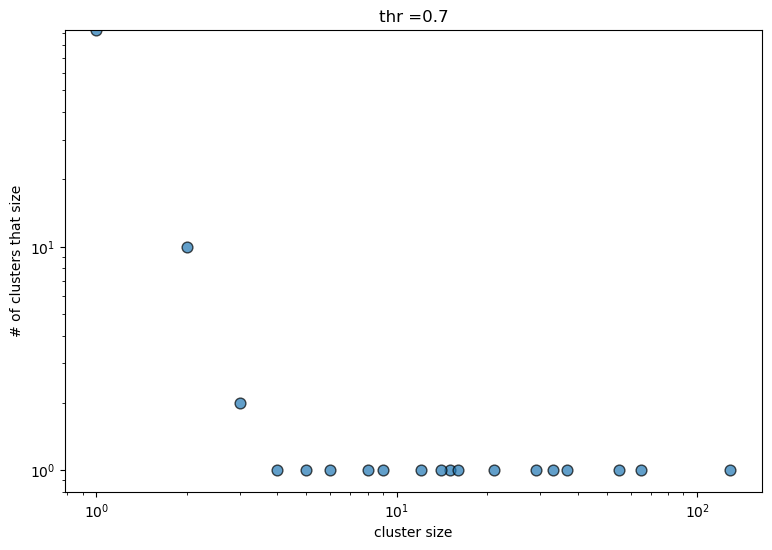

In [19]:
clsgrf=pd.read_csv("../mouseex-muscle-new-model/results/muscle-net-cls.txt",delim_whitespace=True, header=None)
thrshld = .7
import numpy as np
from matplotlib import pyplot as plt
x = list(clsgrf[1].value_counts().index)
y = list(clsgrf[1].value_counts().values)
fig, ax = plt.subplots(figsize = (9, 6))
ax.scatter(x, y, s=60, alpha=0.7, edgecolors="k")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("cluster size")
ax.set_ylabel("# of clusters that size")
ax.set_title("thr ="+str(thrshld))
ax.set_ylim([0, max(y)])

In [ ]:
ana = bone.IBDAnalysis()
ana.getPanda2024MuscleOnlynoSol()
res = []
index = 0
good_res_all = []
good_nodes_all = {}
good_big_nodes_all = {}
for k in G: #would results change if i increase the search space from G (top 10 and connecting) to all of clusters[]?
    l1 = [clusters[k]]
    wt1 = [1]
    print(index, k, ana.h.getSimpleName(k))
    c_dict, fpr, tpr, roc_auc = bone.processGeneGroups(ana, l1, wt1)
    if roc_auc >= .66 or roc_auc <= .33:
        good_res_all += [[c_dict, fpr, tpr, roc_auc]]
        good_nodes_all[k] = [index, ana.h.getSimpleName(k), roc_auc, len(l1[0])]
        if len(l1[0]) >= 10:
            good_big_nodes_all[k] = [index, k, ana.h.getSimpleName(k), roc_auc, len(l1[0])]
    res += [[c_dict, fpr, tpr, roc_auc]]
    index +=1


panda-maier-MuscleNoSoleus-mouse-exercise-tpm-2023 (n = 168)
Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex3
168 [84, 84] Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex3 mmex3
0 ENSMUSG00000038594 Cep85l
[65]
ROC-AUC 0.43
[-19.42855257157597, 174.55759678854247, -19.92855257157597, -18.92855257157597]
4.08975990941392 -19.42855257157597
1 ENSMUSG00000008318 Relt
[15]
ROC-AUC 0.56
[-4.304878117532266, 226.197849743573, -4.804878117532266, -3.804878117532266]
1.0003558522409512 -4.304878117532266
2 ENSMUSG00000027204 Fbn1
[2]
ROC-AUC 0.53
[-0.5495959573808198, 160.38029109201182, -1.0495959573808198, -0.04959595738081979]
0.1801153112699464 -0.5495959573808198
3 ENSMUSG00000030336 Cd27
[55]
ROC-AUC 0.52
[-14.102847361513223, 385.25209877450567, -14.602847361513223, -13.602847361513223]
3.0744478098075554 -14.102847361513223
4 ENSMUSG00000022490 Ppp1r1a
[14]
ROC-AUC 0.33
[-4.096971335674998, 205.47343536560348

In [21]:
ana = bone.IBDAnalysis()
ana.getPanda2024MuscleOnly(2,"Quad")
res = []
index = 0
good_res_quad = []
good_nodes_quad = {}
good_big_nodes_quad = {}
for k in G:
    l1 = [clusters[k]]
    wt1 = [1]
    print(index, k, ana.h.getSimpleName(k))
    c_dict, fpr, tpr, roc_auc = bone.processGeneGroups(ana, l1, wt1)
    if roc_auc >= .66 or roc_auc <= .33:
        good_res_quad += [[c_dict, fpr, tpr, roc_auc]]
        good_nodes_quad[k] =[index, k, ana.h.getSimpleName(k), roc_auc, len(l1[0])]
        if len(l1[0]) >= 10:
            good_big_nodes_quad[k] = [index, k, ana.h.getSimpleName(k), roc_auc, len(l1[0])]
    res += [[c_dict, fpr, tpr, roc_auc]]
    index +=1

panda-maier-MuscleOnly-mouse-exercise-tpm-2023 (n = 192)
Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex2
24 [12, 12] Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex2 mmex2
0 ENSMUSG00000038594 Cep85l
[65]
ROC-AUC 0.38
[-13.560826368884955, 24.678721788967287, -14.060826368884955, -13.060826368884955]
3.8835228480003012 -13.560826368884955
1 ENSMUSG00000008318 Relt
[15]
ROC-AUC 0.49
[-2.2012195049317977, 32.643393162430186, -2.7012195049317977, -1.7012195049317977]
0.9150043499590623 -2.2012195049317977
2 ENSMUSG00000027204 Fbn1
[2]
ROC-AUC 0.48
[-0.10610899184669645, 32.92212405801427, -0.6061089918466964, 0.3938910081533036]
0.18951936586763368 -0.10610899184669645
3 ENSMUSG00000030336 Cd27
[55]
ROC-AUC 0.56
[-11.826759305660406, 147.269515932536, -12.326759305660406, -11.326759305660406]
2.983720661288233 -11.826759305660406
4 ENSMUSG00000022490 Ppp1r1a
[14]
ROC-AUC 0.26
[-2.9566167291850047, 26.8502260812

In [22]:
#all nodes with ok predictive value (.66 < x < .33)
print('allns:',*[ana.h.getSimpleName(k) for k in good_nodes_all])
print('quad: ',*[ana.h.getSimpleName(k) for k in good_nodes_quad])
#all big nodes with ok predictive value (.66 < x < .33) (more than 10 genes)
print("big nodes:")
print('allns:',*[ana.h.getSimpleName(k) for k in good_big_nodes_all])
print('quad: ',*[ana.h.getSimpleName(k) for k in good_big_nodes_quad])

allns: Ppp1r1a Cyfip2 Egln3 Prune2 Lincmd1 Rgs2
quad:  Ppp1r1a Cyfip2 Myh6 Sntb1 Egln3 Chad Prune2 Lincmd1 Rgs2 Fam83d Mup22 Gm12248
big nodes:
allns: Ppp1r1a Egln3
quad:  Ppp1r1a Myh6 Sntb1 Egln3 Chad


In [23]:
ana = bone.IBDAnalysis()
tissuedict = {'allns':good_nodes_all}
tissuedict_big = {'allns':good_big_nodes_all}
print("allns",":",tissuedict_big["allns"], sep = '\t')
for tissue in ['BF', 'EDL', 'Gas', 'Quad', 'SM', 'ST','Sol','TA']:
    with HiddenPrints(): ana.getPanda2024MuscleOnly(2,tissue)
    index = 0
    good_nodes = {}
    good_big_nodes = {}
    for k in G:
        l1 = [clusters[k]];wt1 = [1]
        with HiddenPrints(): ana.orderData(l1, wt1)
        roc_auc = float(ana.getMetrics())
        if roc_auc >= .7 or roc_auc <= .3:
            good_nodes[k] =[index, ana.h.getSimpleName(k), roc_auc, len(l1[0])]
            if len(l1[0]) >= 10:
                good_big_nodes[k] = [index, ana.h.getSimpleName(k), roc_auc, len(l1[0])]
        index +=1
    print(tissue,":",good_big_nodes, sep="\t")
    tissuedict[tissue] = good_nodes
    tissuedict_big[tissue] = good_big_nodes
kll = [list(tissuedict[d].keys()) for d in tissuedict.keys()] #in the for loop? why?



allns	:	{'ENSMUSG00000022490': [4, 'ENSMUSG00000022490', 'Ppp1r1a', np.float64(0.32893990929705214), 14], 'ENSMUSG00000035105': [9, 'ENSMUSG00000035105', 'Egln3', np.float64(0.9448696145124716), 33]}
BF	:	{'ENSMUSG00000022490': [4, 'Ppp1r1a', 0.26, 14], 'ENSMUSG00000060429': [7, 'Sntb1', 0.08, 16], 'ENSMUSG00000035105': [9, 'Egln3', 1.0, 33]}
EDL	:	{'ENSMUSG00000022490': [4, 'Ppp1r1a', 0.28, 14], 'ENSMUSG00000060429': [7, 'Sntb1', 0.76, 16], 'ENSMUSG00000035105': [9, 'Egln3', 0.97, 33], 'ENSMUSG00000039084': [10, 'Chad', 0.29, 29], 'ENSMUSG00000098973': [12, 'Mir6236', 0.24, 21]}
Gas	:	{'ENSMUSG00000022490': [4, 'Ppp1r1a', 0.26, 14], 'ENSMUSG00000040752': [6, 'Myh6', 0.72, 37], 'ENSMUSG00000060429': [7, 'Sntb1', 0.12, 16], 'ENSMUSG00000035105': [9, 'Egln3', 1.0, 33]}
Quad	:	{'ENSMUSG00000022490': [4, 'Ppp1r1a', 0.26, 14], 'ENSMUSG00000040752': [6, 'Myh6', 0.28, 37], 'ENSMUSG00000060429': [7, 'Sntb1', 0.17, 16], 'ENSMUSG00000035105': [9, 'Egln3', 1.0, 33], 'ENSMUSG00000039084': [10, 'Ch

In [24]:
kl = []
for k in kll: kl = kl + k
rdf = pd.DataFrame(kl, columns=['ID']).value_counts().reset_index(name='NumTissuesSig')
rdf["name"] = [ana.h.getSimpleName(k) for k in rdf["ID"]]
rdf['size'] = [len(clusters[k]) for k in rdf['ID']]
tlst = []
auclst = []
for i in rdf['ID']:
    cl = []
    clauc = []
    for k in tissuedict.keys():
        if i in tissuedict[k].keys():
            cl = cl+[k]
            clauc = clauc + [round(tissuedict[k][i][2],2)]
    tlst = tlst + [cl]
    auclst = auclst + [clauc]
rdf['tissues'] = tlst
rdf['auc'] = auclst
rdf['avg_auc'] = [round(statistics.mean(i),2) for i in rdf['auc']]
topdf = rdf[rdf["NumTissuesSig"] >= 1][rdf["size"] >= 2]
topdf

,ID,NumTissuesSig,name,size,tissues,auc,avg_auc
0,ENSMUSG00000020340,8,Cyfip2,4,"[allns, BF, EDL, Gas, Quad, SM, ST, TA]","[0.74, 0.77, 0.75, 0.74, 0.74, 0.75, 0.78, 0.75]",0.75
1,ENSMUSG00000035105,8,Egln3,33,"[allns, BF, EDL, Gas, Quad, SM, ST, TA]","[0.94, 1.0, 0.97, 1.0, 1.0, 1.0, 0.96, 0.8]",0.96
2,ENSMUSG00000022490,6,Ppp1r1a,14,"[allns, BF, EDL, Gas, Quad, SM]","[0.33, 0.26, 0.28, 0.26, 0.26, 0.26]",0.28
3,ENSMUSG00000060429,6,Sntb1,16,"[BF, EDL, Gas, Quad, SM, ST]","[0.08, 0.76, 0.12, 0.17, 0.12, 0.74]",0.33
4,ENSMUSG00000039126,5,Prune2,2,"[allns, BF, Gas, Quad, SM]","[0.68, 0.76, 0.85, 0.97, 0.8]",0.81
7,ENSMUSG00000023047,4,Amhr2,2,"[BF, Gas, SM, Sol]","[0.28, 0.29, 0.21, 0.72]",0.38
9,ENSMUSG00000040752,4,Myh6,37,"[Gas, Quad, SM, Sol]","[0.72, 0.28, 0.74, 0.73]",0.62
10,ENSMUSG00000110439,3,Mup22,3,"[Quad, SM, ST]","[0.74, 0.74, 0.83]",0.77
12,ENSMUSG00000039084,3,Chad,29,"[EDL, Quad, ST]","[0.29, 0.17, 0.72]",0.39
14,ENSMUSG00000030336,1,Cd27,55,[Sol],[0.74],0.74


In [ ]:
print("ALL GOOD CLUSTERS \n")
ana = bone.IBDAnalysis()
w = [1]
with HiddenPrints(): ana.getPanda2024Exercise()
for i in range(len(topdf)):
    print(topdf['name'][i],"\t:\t", *[ana.h.getSimpleName(k) for k in clusters[topdf['ID'][i]]],end='\n \n')
    for tissue in tissuedict:
        if topdf['ID'][i] in tissuedict[tissue].keys():
            print(tissue, ":", tissuedict[tissue][topdf['ID'][i]][2], sep = "\t")
        else:
            with HiddenPrints(): #check how Ppp1r1a predicts in Sol
                ana.getPanda2024MuscleOnly(2,tissue) 
                fullcls = [clusters[topdf['ID'][i]]]
                ana.orderData(fullcls, w)
            print(tissue,"\t:\t",ana.getMetrics(),"\t","not sig")
    print("\n")
print('ROC-AUC')

In [13]:
print("ALL GOOD CLUSTERS BIGGER THAN 1 GENE \n")
ana = bone.IBDAnalysis()
with HiddenPrints(): ana.getPanda2024Exercise()
w = [1]
for i in range(len(topdf)):
    if(len(clusters[topdf['ID'][i]]) > 1):
        print(topdf['name'][i],"\t:\t", *[ana.h.getSimpleName(k) for k in clusters[topdf['ID'][i]]],end='\n \n')
        for tissue in tissuedict:
            if topdf['ID'][i] in tissuedict[tissue].keys():
                print(tissue, ":", tissuedict[tissue][topdf['ID'][i]][2], sep = "\t")
            else:
                with HiddenPrints(): #check how Ppp1r1a predicts in Sol
                    ana.getPanda2024MuscleOnly(2,tissue) 
                    fullcls = [clusters[topdf['ID'][i]]]
                    ana.orderData(fullcls, w)
                print(tissue,"\t:\t",ana.getMetrics(),"\t not sig")
        print("\n")
print('ROC-AUC')

ALL GOOD CLUSTERS BIGGER THAN 1 GENE 

Cyfip2 	:	 Cyfip2 H19 Lrfn4 Ak4
 
allns	:	0.7413548752834467
BF	:	0.77
EDL	:	0.75
Gas	:	0.74
Quad	:	0.74
SM	:	0.75
ST	:	0.78
Sol	:	0.69
TA	:	0.75


Egln3 	:	 Egln3 Mb Vgll2 Bdh1 Dusp18 Myh1 Csrp3 Actn2 Idh2 Ldhb Ankrd2 Gm5532 Fxyd6 Ppara Lrrc52 Myom3 Fabp3-ps1 Slc25a34 Lmcd1 Myoz2 Hspb7 Myh2 Slc26a10 Fhl1 Abhd18 Ttc9 BC048679 Casq2 Gm15543 Dgat2 Fabp3 Atp1b1 Atf3
 
allns	:	0.9448696145124716
BF	:	1.0
EDL	:	0.97
Gas	:	1.0
Quad	:	1.0
SM	:	1.0
ST	:	0.96
Sol 	:	 0.53 	 not sig
TA	:	0.8


Ppp1r1a 	:	 Ppp1r1a Gm12514 Gstm2 Gm47708 Fbp2 Fgfbp1 Gm15337 Xist Cdkn1a Pla2g5 Aebp1 Kazald1 Stc2 Neu2
 
allns	:	0.32893990929705214
BF	:	0.26
EDL	:	0.28
Gas	:	0.26
Quad	:	0.26
SM	:	0.26
ST	:	0.33
Sol 	:	 0.40 	 not sig
TA 	:	 0.39 	 not sig


ROC-AUC


In [9]:
def printAucIndvGenes(clsid,tissue):
    if not clsid.startswith("ENSMUSG"):
        clsid = list(ana.h.getIDs(clsid).keys())[0]
    print(tissue,clsid,ana.h.getSimpleName(clsid)) 
    with HiddenPrints(): #check how Ppp1r1a predicts in Sol
        ana.getPanda2024MuscleOnly(2,tissue)
        fullcls = clusters[clsid]
        ana.orderData([fullcls], [1])
    
    print("all",len(clusters[clsid]),ana.getMetrics(), sep = "\t")
    print()
    for gene in clusters[clsid]:
        with HiddenPrints():
            ana.orderData([[gene]], [1])
        print(gene,ana.h.getSimpleName(gene),ana.getMetrics(), sep="\t")
printAucIndvGenes('Sntb1','Sol')

Sol ENSMUSG00000060429 Sntb1
all	16	0.62

ENSMUSG00000060429	Sntb1	0.88
ENSMUSG00000068606	Gm4841	0.58
ENSMUSG00000050069	Grem2	0.32
ENSMUSG00000000305	Cdh4	0.51
ENSMUSG00000033083	Tbc1d4	0.01
ENSMUSG00000031109	Enox2	0.58
ENSMUSG00000049999	Ppp1r3d	0.62
ENSMUSG00000091078	Gm17218	0.11
ENSMUSG00000102329	Gm10851	0.37
ENSMUSG00000026012	Cd28	0.63
ENSMUSG00000025129	Ppp1r27	0.72
ENSMUSG00000051980	Casr	0.54
ENSMUSG00000076617	Ighm	0.74
ENSMUSG00000113739	Gm48584	0.24
ENSMUSG00000075330	A930003A15Rik	1.00
ENSMUSG00000087404	Gm11752	0.10


In [ ]:
def printAucGenesMuscles(gid):
    if not gid.startswith("ENSMUSG"):
        gid = list(ana.h.getIDs(gid).keys())[0]
    print(gid,ana.h.getSimpleName(gid))
    for m in  ['BF', 'EDL', 'Gas', 'Quad', 'SM', 'ST', "TA", "Sol"]:
        with HiddenPrints(): #check how Ppp1r1a predicts in Sol
            ana.getPanda2024MuscleOnly(2,m)
            ana.orderData([[gid]], [1])
        print(m,ana.getMetrics(), sep="\t")
printAucGenesMuscles('Egln3')

In [106]:
ana.getPanda2024MuscleOnly()
def getGeneAUCs(clslist):
    outdf = pd.DataFrame(columns=['tissue','clustername','gene','auc','cluster','id'])
    for c in clslist:
        if not c.startswith("ENSMUSG"):
            c = list(ana.h.getIDs(c).keys())[0]
        ccls = clusters[c]
        #cdf = pd.DataFrame(columns=['tissue','clustername','gene','auc','cluster','id'])
        for m in  ['BF', 'EDL', 'Gas', 'Quad', 'SM', 'ST', "TA", "Sol"]:
            for gene in ccls:
                with HiddenPrints(): #check how Ppp1r1a predicts in Sol
                    ana.getPanda2024MuscleOnly(2,m)
                    ana.orderData([[gene]], [1])
                outdf.loc[len(outdf)]=[m,ana.h.getSimpleName(c),ana.h.getSimpleName(gene),float(ana.getMetrics()),c,gene]
    return outdf
Sntb1AUCs = getGeneAUCs(['Sntb1'])
Sntb1AUCs['absauc'] = (abs(Sntb1AUCs['auc']-.5)+.5)
            

panda-maier-MuscleOnly-mouse-exercise-tpm-2023 (n = 192)
Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex2
192 [96, 96] Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex2 mmex2


Cyfip2, predictive in all in the 70s, but small.         cls5,  4 genes, ENSMUSG00000020340

Egln highly predictive in all, but not the soleus.       cls9, 33 genes, ENSMUSG00000035105 

Ppp1r1a predictive in all in the 30s, but soleus & TA.  cls4, 14 genes, ENSMUSG00000022490

PLOTTING THE FULL CLUSTERS ON OUR DATA

In [8]:
print('Egln3 = ',clusters['ENSMUSG00000035105'])
print('Cyfip2 = ',clusters['ENSMUSG00000020340'])
print('Ppp1r1a = ',clusters['ENSMUSG00000022490'])

Egln3 =  ['ENSMUSG00000035105', 'ENSMUSG00000018893', 'ENSMUSG00000049641', 'ENSMUSG00000046598', 'ENSMUSG00000047205', 'ENSMUSG00000056328', 'ENSMUSG00000030470', 'ENSMUSG00000052374', 'ENSMUSG00000030541', 'ENSMUSG00000030246', 'ENSMUSG00000025172', 'ENSMUSG00000073535', 'ENSMUSG00000066705', 'ENSMUSG00000022383', 'ENSMUSG00000040485', 'ENSMUSG00000037139', 'ENSMUSG00000056366', 'ENSMUSG00000040740', 'ENSMUSG00000057604', 'ENSMUSG00000028116', 'ENSMUSG00000006221', 'ENSMUSG00000033196', 'ENSMUSG00000040441', 'ENSMUSG00000023092', 'ENSMUSG00000037818', 'ENSMUSG00000042734', 'ENSMUSG00000061877', 'ENSMUSG00000027861', 'ENSMUSG00000086863', 'ENSMUSG00000030747', 'ENSMUSG00000028773', 'ENSMUSG00000026576', 'ENSMUSG00000026628']
Cyfip2 =  ['ENSMUSG00000020340', 'ENSMUSG00000000031', 'ENSMUSG00000045045', 'ENSMUSG00000028527']
Ppp1r1a =  ['ENSMUSG00000022490', 'ENSMUSG00000087614', 'ENSMUSG00000040562', 'ENSMUSG00000112188', 'ENSMUSG00000021456', 'ENSMUSG00000048373', 'ENSMUSG00000085289',

33 4 14 51
panda-maier-mouse-exercise-tpm-2023 (n = 575)
Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex1
575 [288, 287] Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex1 mmex1
all: 0.9392307692307693
muscles: 0.95625
sol: 0.74


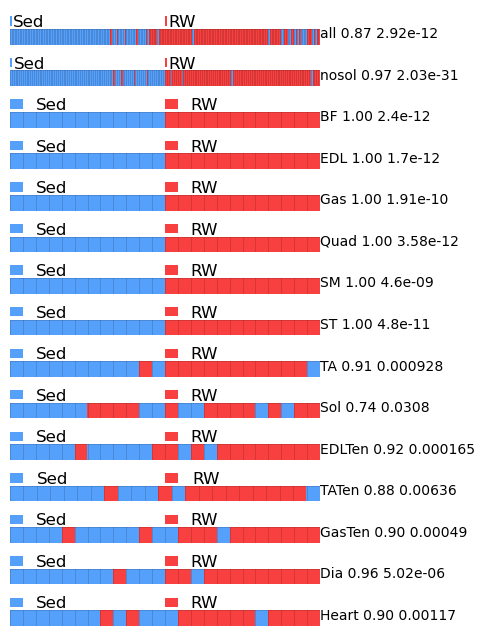

In [3]:
#PLOTTING THE FULL CLUSTERS ON OUR DATA
Egln3   = clusters['ENSMUSG00000035105']
Cyfip2  = clusters['ENSMUSG00000020340']
Ppp1r1a = clusters['ENSMUSG00000022490']
l1 = [Egln3,Cyfip2,Ppp1r1a]
print(len(Egln3),len(Cyfip2),len(Ppp1r1a),len(Egln3)+len(Cyfip2)+len(Ppp1r1a))
#wt1 = [1,1,-1] #a0.92769 m0.94875 sol: 0.67
#wt1 = [1,0,0]  #a0.89923 m0.93499 sol: 0.72
#wt1 = [1,1,0]  #a0.89307 m0.931249 sol: 0.76
#wt1 = [1,0,-1] #a0.920769 m0.94375 sol: 0.65
#wt1 = [4,3,-4] #a0.92846 m0.9475 sol: 0.67
#wt1 = [3,1,-2] #a0.933846 m0.95375 sol: 0.72
#wt1 = [4,3,-3]     #a0.93923 m0.95625 sol: 0.74
#wt1 = [1,.75,-.75] #a0.93923 m0.95625 sol: 0.74
#wt1 = [1,.75,-.8]  #a0.934615 m0.95375 sol: 0.72

wt1 = [1,.75,-.75]

ana = bone.IBDAnalysis()
#ana.getPanda2024MuscleOnly()

tissues = ['BF', 'EDL', 'Gas', 'Quad', 'SM', 'ST', "TA", "Sol",   
           "EDLTen","TATen","GasTen","Dia","Heart"]#,"epididWAT"] #also "epididWAT" #hu.uniq(ana.h.getSurvName("c Tissue")[2:])
fig,axes = bone.plt.subplots(ncols=1, nrows=len(tissues)+2, figsize=(4,8), dpi=100)
aucAvg = []
with HiddenPrints():
    ana = bone.IBDAnalysis()
    ana.getPanda2024MuscleOnly()
    ana.orderData(l1, wt1)
plotTitleBar(ana, axes[0], "all")
#with HiddenPrints(): #separate soleus, the stats didnt work correctly
#    ana = bone.IBDAnalysis()
#    ana.getPanda2024MuscleOnly(3)
#    ana.orderData(l1, wt1)
#plotTitleBar(ana, axes[1], "all")
with HiddenPrints():
    ana = bone.IBDAnalysis()
    ana.getPanda2024MuscleOnlynoSol()
    ana.orderData(l1, wt1)
plotTitleBar(ana, axes[1], "nosol")
ana.getPanda2024Exercise()
for ii in range(len(tissues)):
    ta = tissues[ii]
    #print(ta)
    with HiddenPrints():
        ana = bone.IBDAnalysis()
        ana.getPanda2024Exercise(2, ta)
        ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[ii+2], ta)
#print(aucAvg)
print('all:', sum(aucAvg)/len(aucAvg))
print('muscles:', sum(aucAvg[0:8])/len(aucAvg[0:8]))
print('sol:', aucAvg[7])

FULL CLUSTERS IN INDEPENDENT DATASETS

panda-maier-mouse-exercise-tpm-2023 (n = 575)
Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex1
575 [288, 287] Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex1 mmex1
panda-maier-MuscleNoSoleus-mouse-exercise-tpm-2023 (n = 168)
Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex3
168 [84, 84] Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex3 mmex3
[33, 4, 14]
Sato 2019, Mus musculus, Circadian exercise in the early rest versus active phase (n = 137)
GSE126962 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M87
137 [69, 68] GSE126962 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M87 M87
[31, 3, 10]
moore2023_mouse_quad_exercise_female (n = 99)
GSE230102 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M105-1
99 [49, 50] GSE230102 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M105-1 M105-1
[31, 3, 10]
Schje

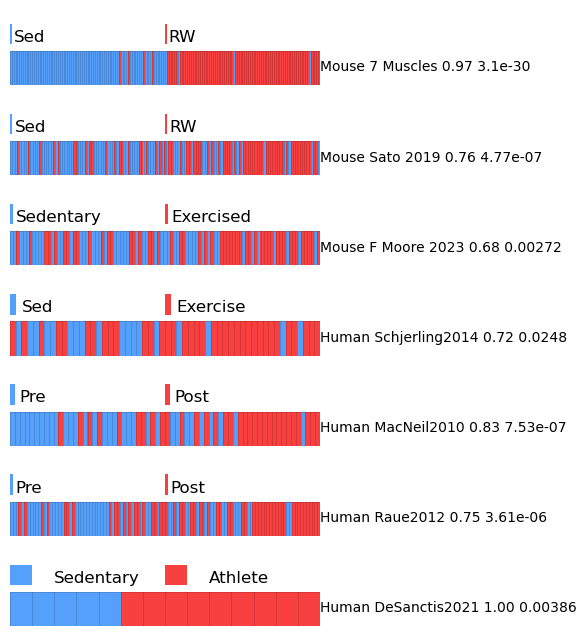

In [5]:
#full clusters in independent datasets
#convert from ensmbl mouse ids to human names
ana = bone.IBDAnalysis()
ana.getPanda2024Exercise()
#mouse names
Egln3_mm = [ana.h.getSimpleName(k) for k in Egln3]
Cyfip2_mm = [ana.h.getSimpleName(k) for k in Cyfip2]
Ppp1r1a_mm = [ana.h.getSimpleName(k) for k in Ppp1r1a]
#human names
Egln3_hs = list(bone.getGroupsHs([Egln3_mm])[0])
Cyfip2_hs = list(bone.getGroupsHs([Cyfip2_mm])[0])
Ppp1r1a_hs = list(bone.getGroupsHs([Ppp1r1a_mm])[0])
l1_mouse = [Egln3,Cyfip2,Ppp1r1a]
l1_hs = [Egln3_hs,Cyfip2_hs,Ppp1r1a_hs]
#wt1 = [1,.75,-.75] #[0.97, 0.74, 0.67, 0.69, 0.83, 0.74] 0.7733333333333333
wt1 = [1,0,-.75]   #[0.97, 0.76, 0.68, 0.72, 0.83, 0.75] 0.785
#wt1 = [1,0,-1]    #[0.98, 0.75, 0.68, 0.73, 0.81, 0.75] 0.7833333333333333
fig,axes = bone.plt.subplots(ncols=1, nrows=7, figsize=(4,8), dpi=100)
aucAvg = []

ana = bone.IBDAnalysis()
ana.getPanda2024MuscleOnlynoSol()
ana.orderData(l1_mouse, wt1)
aucAvg += [float(ana.getMetrics())]
plotTitleBar(ana, axes[0], "Mouse 7 Muscles")

ana = bone.IBDAnalysis()
ana.getSato2019()
ana.orderData(l1_mouse, wt1)
aucAvg += [float(ana.getMetrics())]
plotTitleBar(ana, axes[1], "Mouse Sato 2019")

ana = bone.IBDAnalysis()
ana.getmoore2023mouse()
ana.orderData(l1_mouse, wt1)
aucAvg += [float(ana.getMetrics())]
plotTitleBar(ana, axes[2], "Mouse F Moore 2023")

ana = bone.IBDAnalysis()
ana.getSchjerling2014()
ana.orderData(l1_hs, wt1)
aucAvg += [float(ana.getMetrics())]
plotTitleBar(ana, axes[3], "Human Schjerling2014")

ana = bone.IBDAnalysis()
ana.getMacNeil2010()
ana.orderData(l1_hs, wt1)
aucAvg += [float(ana.getMetrics())]
plotTitleBar(ana, axes[4], "Human MacNeil2010")

ana = bone.IBDAnalysis()
ana.getRaue2012()
ana.orderData(l1_hs, wt1)
aucAvg += [float(ana.getMetrics())]
plotTitleBar(ana, axes[5], "Human Raue2012")
print(aucAvg)
print(sum(aucAvg)/len(aucAvg))

ana = bone.IBDAnalysis()
ana.getDeSanctis2021()
ana.orderData(l1_hs, wt1)
aucAvg += [float(ana.getMetrics())]
plotTitleBar(ana, axes[6], "Human DeSanctis2021")
print(aucAvg)
print(sum(aucAvg)/len(aucAvg))



test in individual muscles and independent datasets

In [22]:
ana = bone.IBDAnalysis()
ana.getPanda2024MuscleOnlynoSol()
ana.h.saveDiff("mf-results/muscleEx_ns-diff.txt", ana.state[1], ana.state[0]) #I SWITCHED 1 and 0 SO THAT POSITIVE MEANS UP IN EXERCISE

panda-maier-MuscleNoSoleus-mouse-exercise-tpm-2023 (n = 168)
Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex3
168 [84, 84] Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex3 mmex3


filter by different number of overlap gene lists 

In [8]:
#get overlaps
up_oxl = pd.read_excel("DEG_Fisher_Up-Down_Muscles.xlsx",sheet_name="UP")
down_oxl = pd.read_excel("DEG_Fisher_Up-Down_Muscles.xlsx",sheet_name="DOWN")

up8=set(up_oxl[up_oxl["TotalEvidenceCount"]==8]['Gene Symbol'])
down8=set(down_oxl[down_oxl["TotalEvidenceCount"]==8]['Gene Symbol'])

up7=set(up_oxl[up_oxl["TotalEvidenceCount"]==7]['Gene Symbol']).union(up8)
down7=set(down_oxl[down_oxl["TotalEvidenceCount"]==7]['Gene Symbol']).union(down8)

up6=set(up_oxl[up_oxl["TotalEvidenceCount"]==6]['Gene Symbol']).union(up7)
down6=set(down_oxl[down_oxl["TotalEvidenceCount"]==6]['Gene Symbol']).union(down7)


up5=set(up_oxl[up_oxl["TotalEvidenceCount"]==5]['Gene Symbol']).union(up6)
down5=set(down_oxl[down_oxl["TotalEvidenceCount"]==5]['Gene Symbol']).union(down6)
print(len(up8),len(up7),len(up6),len(up5))

45 243 558 1044


In [5]:
up_oxl[up_oxl['Gene Symbol'].isin(up6)]
#down = down_oxl[down_oxl['Gene Symbol'].isin(down6)]

,Gene,original_id,BF,EDL,Gas,Quad,SM,ST,Sol,TA,Gene Symbol,Description,Biological Process (GO),Kinase Class (UniProt),Secreted (UniProt),TotalEvidenceCount
0,68728,ENSMUSG00000038375,1,1,1,1,1,1,1,1,Trp53inp2,transformation related protein 53 inducible nu...,GO:0000045 autophagosome assembly;GO:1905037 a...,NaN,NaN,8
1,170721,ENSMUSG00000021223,1,1,1,1,1,1,1,1,Papln,"papilin, proteoglycan-like sulfated glycoprotein",GO:0010466 negative regulation of peptidase ac...,NaN,yes,8
2,14688,ENSMUSG00000029064,1,1,1,1,1,1,1,1,Gnb1,guanine nucleotide binding protein (G protein)...,"GO:0007603 phototransduction, visible light;GO...",NaN,NaN,8
3,67231,ENSMUSG00000027465,1,1,1,1,1,1,1,1,Tbc1d20,"TBC1 domain family, member 20",GO:0046726 positive regulation by virus of vir...,NaN,NaN,8
4,52065,ENSMUSG00000070056,1,1,1,1,1,1,1,1,Mfhas1,malignant fibrous histiocytoma amplified seque...,GO:0034136 negative regulation of toll-like re...,NaN,NaN,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553,68087,ENSMUSG00000020935,1,0,1,1,1,1,1,0,Dcakd,dephospho-CoA kinase domain containing,GO:0015937 coenzyme A biosynthetic process;GO:...,NaN,NaN,6
554,52822,ENSMUSG00000029291,1,0,1,1,1,1,1,0,Rufy3,RUN and FYVE domain containing 3,GO:2000114 regulation of establishment of cell...,NaN,NaN,6
555,226971,ENSMUSG00000026123,1,1,1,1,1,0,0,1,Plekhb2,"pleckstrin homology domain containing, family ...",GO:0045595 regulation of cell differentiation;...,NaN,NaN,6
556,108116,ENSMUSG00000025790,1,1,1,1,1,1,0,0,Slco3a1,solute carrier organic anion transporter famil...,GO:0015732 prostaglandin transport;GO:0043252 ...,NaN,NaN,6


[{'Egln3', 'Dusp18', 'Ldhb', 'Myh2', 'Ankrd2', 'Actn2', 'Myh1', 'Mb', 'Vgll2', 'Fabp3', 'Atf3', 'Bdh1', 'Lmcd1', 'Gm5532', 'Csrp3', 'BC048679', 'Casq2', 'Myom3', 'Fxyd6', 'Fhl1', 'Ttc9', 'Slc26a10', 'Hspb7'}, {'Ak4', 'H19'}, {'Pla2g5', 'Fbp2', 'Fgfbp1', 'Gstm2', 'Neu2'}]
30
[['FXYD6', 'LMCD1', 'AC010197.2', 'ATF3', 'ACTN2', 'FHL1', 'DUSP18', 'CSRP3', 'LDHB', 'SLC26A10', 'MYH1', 'CASQ2', 'HSPB7', 'FABP3', 'TTC9', 'MYOM3', 'BDH1', 'MB', 'VGLL2', 'ANKRD2', 'EGLN3'], ['AK4'], ['PLA2G5', 'GSTM1', 'FBP2', 'FGFBP1', 'NEU2']]
panda-maier-MuscleNoSoleus-mouse-exercise-tpm-2023 (n = 168)
Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex3
168 [84, 84] Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex3 mmex3
[23, 2, 5]
Sato 2019, Mus musculus, Circadian exercise in the early rest versus active phase (n = 137)
GSE126962 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M87
137 [69, 68] GSE126962 http://hegemon.ucsd.edu/

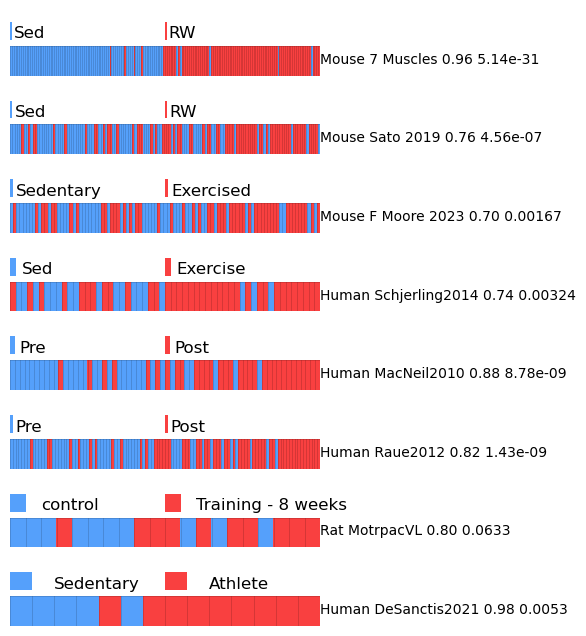

In [ ]:
#Final Signature
#DEG SHARED IN 6 TISSUE OVERLAP
l1 = [set(up6).intersection(Egln3_mm), #could make this more strict later w upstrictdiffex
     set(up6).intersection(Cyfip2_mm),
     set(down6).intersection(Ppp1r1a_mm)]
l1_hs = [list(bone.getGroupsHs([l1[0]])[0]),list(bone.getGroupsHs([l1[1]])[0]),list(bone.getGroupsHs([l1[2]])[0])]
print(l1)
print(len(l1[0])+len(l1[1])+len(l1[2]))    
print(l1_hs) 
#wt1 = [1,0,-.5] 
wt1 = [1,1,-1]      #[0.96, 0.76, 0.7, 0.74, 0.88, 0.82, 0.8, 0.98] 0.8300000000000001
#wt1 = [1,.75,-.75] #[0.96, 0.76, 0.69, 0.72, 0.89, 0.81, 0.77, 0.98] 0.8225
#wt1 = [2,1,-1]     #[0.96, 0.77, 0.68, 0.7, 0.89, 0.81, 0.76, 0.98] 0.8187500000000001
fig,axes = bone.plt.subplots(ncols=1, nrows=8, figsize=(4,8), dpi=100)
aucAvg = []
ana = bone.IBDAnalysis()
ana.getPanda2024MuscleOnlynoSol()
ana.orderData(l1, wt1)
aucAvg += [float(ana.getMetrics())]
plotTitleBar(ana, axes[0], "Mouse 7 Muscles")

ana = bone.IBDAnalysis()
ana.getSato2019()
ana.orderData(l1, wt1)
aucAvg += [float(ana.getMetrics())]
plotTitleBar(ana, axes[1], "Mouse Sato 2019")

ana = bone.IBDAnalysis()
ana.getmoore2023mouse()
ana.orderData(l1, wt1)
aucAvg += [float(ana.getMetrics())]
plotTitleBar(ana, axes[2], "Mouse F Moore 2023")

ana = bone.IBDAnalysis()
ana.getSchjerling2014()
ana.orderData(l1, wt1)
aucAvg += [float(ana.getMetrics())]
plotTitleBar(ana, axes[3], "Human Schjerling2014")

ana = bone.IBDAnalysis()
ana.getMacNeil2010()
ana.orderData(l1, wt1)
aucAvg += [float(ana.getMetrics())]
plotTitleBar(ana, axes[4], "Human MacNeil2010")

ana = bone.IBDAnalysis()
ana.getRaue2012()
ana.orderData(l1, wt1)
aucAvg += [float(ana.getMetrics())]
plotTitleBar(ana, axes[5], "Human Raue2012")

ana = bone.IBDAnalysis()
ana.getMotrpacVL(8)
ana.orderData(l1, wt1)
aucAvg += [float(ana.getMetrics())]
plotTitleBar(ana, axes[6], "Rat MotrpacVL")

ana = bone.IBDAnalysis()
ana.getDeSanctis2021()
ana.orderData(l1_hs, wt1)
aucAvg += [float(ana.getMetrics())]
plotTitleBar(ana, axes[7], "Human DeSanctis2021")

print(aucAvg)
print(sum(aucAvg)/len(aucAvg))
plt.savefig("ROC-AUC-BARS_validation.pdf", transparent=True, bbox_inches = 'tight')

In [10]:
ana = bone.IBDAnalysis()
with HiddenPrints(): ana.getRaue2012()
RaueGenes6 = {}
print(l1)
ind=0
for clst in l1:
    with HiddenPrints(): ana.orderData([clst], [1])
    RaueGenes6[ind] = float(ana.getMetrics())
    ind+=1
print(RaueGenes6)
with HiddenPrints(): ana.getMacNeil2010()
MacNeil6 = {}
ind=0
for clst in l1:
    with HiddenPrints(): ana.orderData([clst], [1])
    MacNeil6[ind] = float(ana.getMetrics())
    ind+=1
print(MacNeil6)
print('mouse')
with HiddenPrints(): ana.getSato2019()
Sato6 = {}
ind=0
for clst in l1:
    with HiddenPrints(): ana.orderData([clst], [1])
    Sato6[ind] = float(ana.getMetrics())
    ind+=1
print(Sato6)
print('gas')
with HiddenPrints(): ana.getMotrpacGas(8)
mpGas6 = {}
ind=0
for clst in l1:
    with HiddenPrints(): ana.orderData([clst], [1])
    mpGas6[ind] = float(ana.getMetrics())
    ind+=1
print(mpGas6)
with HiddenPrints(): ana.getPanda2024Exercise(2,"Gas")
mouseGas6 = {}
ind=0
for clst in l1:
    with HiddenPrints(): ana.orderData([clst], [1])
    mouseGas6[ind] = float(ana.getMetrics())
    ind+=1
print(mouseGas6)

[{'BC048679', 'Bdh1', 'Atf3', 'Fhl1', 'Egln3', 'Myh2', 'Fabp3', 'Slc26a10', 'Lmcd1', 'Myom3', 'Actn2', 'Vgll2', 'Ldhb', 'Ankrd2', 'Hspb7', 'Casq2', 'Dusp18', 'Gm5532', 'Mb', 'Csrp3', 'Fxyd6', 'Myh1', 'Ttc9'}, {'Ak4', 'H19'}, {'Pla2g5', 'Neu2', 'Fbp2', 'Fgfbp1', 'Gstm2'}]
{0: 0.79, 1: 0.56, 2: 0.46}
{0: 0.88, 1: 0.5, 2: 0.43}
mouse
{0: 0.77, 1: 0.54, 2: 0.45}
gas
{0: 0.2, 1: 0.69, 2: 0.21}
{0: 1.0, 1: 0.75, 2: 0.26}


[{'Bdh1', 'Casq2', 'Gm5532', 'BC048679', 'Vgll2', 'Actn2', 'Ldhb', 'Fabp3', 'Fhl1', 'Slc26a10', 'Myom3', 'Ttc9', 'Myh2', 'Csrp3', 'Atf3', 'Lmcd1', 'Mb', 'Fxyd6', 'Myh1', 'Ankrd2', 'Egln3', 'Dusp18', 'Hspb7'}, {'H19', 'Ak4'}, {'Pla2g5', 'Gstm2', 'Fgfbp1', 'Neu2', 'Fbp2'}]
30
[['FABP3', 'FHL1', 'SLC26A10', 'LDHB', 'VGLL2', 'MB', 'ATF3', 'LMCD1', 'MYOM3', 'HSPB7', 'FXYD6', 'ACTN2', 'DUSP18', 'MYH1', 'AC010197.2', 'CSRP3', 'BDH1', 'ANKRD2', 'EGLN3', 'CASQ2', 'TTC9'], ['AK4'], ['PLA2G5', 'FBP2', 'GSTM1', 'NEU2', 'FGFBP1']]
panda-maier-mouse-exercise-tpm-2023 (n = 575)
Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex1
575 [288, 287] Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex1 mmex1
all: 0.9166666666666666
muscles: 0.97875
sol: 1.0


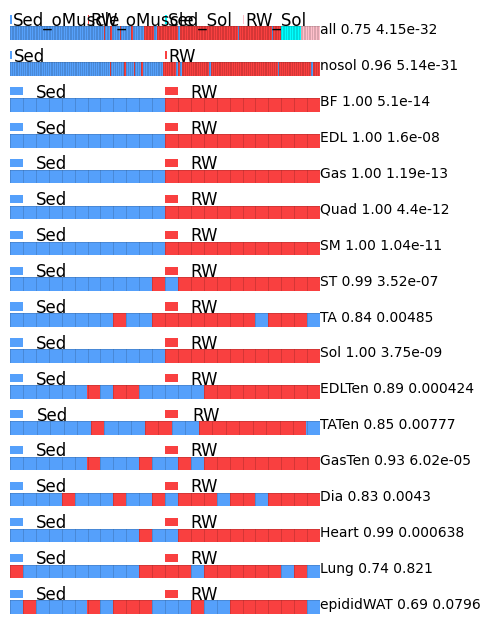

In [110]:
#test each individual muscle 

l1 = [set(up6).intersection(Egln3_mm), #could make this more strict later w upstrictdiffex
     set(up6).intersection(Cyfip2_mm),
     set(down6).intersection(Ppp1r1a_mm)]
l1_hs = [list(bone.getGroupsHs([l1[0]])[0]),list(bone.getGroupsHs([l1[1]])[0]),list(bone.getGroupsHs([l1[2]])[0])]
print(l1)
print(len(l1[0])+len(l1[1])+len(l1[2]))    
print(l1_hs) 
wt1 = [1,1,-1]

ana = bone.IBDAnalysis()
#ana.getPanda2024MuscleOnly()

tissues = ['BF', 'EDL', 'Gas', 'Quad', 'SM', 'ST', "TA", "Sol",   
           "EDLTen","TATen","GasTen","Dia","Heart","Lung","epididWAT"]#,"epididWAT"] #also "epididWAT" #hu.uniq(ana.h.getSurvName("c Tissue")[2:])
fig,axes = bone.plt.subplots(ncols=1, nrows=len(tissues)+2, figsize=(4,8), dpi=100)
aucAvg = []
with HiddenPrints():
    ana = bone.IBDAnalysis()
    ana.getPanda2024MuscleOnly(3)
    ana.orderData(l1, wt1)
plotTitleBar(ana, axes[0], "all")
#with HiddenPrints(): #separate soleus, the stats didnt work correctly
#    ana = bone.IBDAnalysis()
#    ana.getPanda2024MuscleOnly(3)
#    ana.orderData(l1, wt1)
#plotTitleBar(ana, axes[1], "all")
with HiddenPrints():
    ana = bone.IBDAnalysis()
    ana.getPanda2024MuscleOnlynoSol()
    ana.orderData(l1, wt1)
plotTitleBar(ana, axes[1], "nosol")
ana.getPanda2024Exercise()
for ii in range(len(tissues)):
    ta = tissues[ii]
    #print(ta)
    with HiddenPrints():
        ana = bone.IBDAnalysis()
        ana.getPanda2024Exercise(2, ta)
        ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[ii+2], ta)
#print(aucAvg)
print('all:', sum(aucAvg)/len(aucAvg))
print('muscles:', sum(aucAvg[0:8])/len(aucAvg[0:8]))
print('sol:', aucAvg[7])
plt.savefig("ROC-AUC-BARS_all_our_tissues.pdf", transparent=True, bbox_inches = 'tight')

[{'BC048679', 'Bdh1', 'Atf3', 'Fhl1', 'Egln3', 'Myh2', 'Fabp3', 'Slc26a10', 'Lmcd1', 'Myom3', 'Actn2', 'Vgll2', 'Ldhb', 'Ankrd2', 'Hspb7', 'Casq2', 'Dusp18', 'Gm5532', 'Mb', 'Csrp3', 'Fxyd6', 'Myh1', 'Ttc9'}, {'Ak4', 'H19'}, {'Pla2g5', 'Neu2', 'Fbp2', 'Fgfbp1', 'Gstm2'}]
30
[['HSPB7', 'MB', 'ANKRD2', 'FHL1', 'FABP3', 'LMCD1', 'ACTN2', 'SLC26A10', 'FXYD6', 'EGLN3', 'AC010197.2', 'MYOM3', 'VGLL2', 'CASQ2', 'BDH1', 'ATF3', 'CSRP3', 'TTC9', 'DUSP18', 'MYH1', 'LDHB'], ['AK4'], ['PLA2G5', 'FBP2', 'NEU2', 'FGFBP1', 'GSTM1']]
panda-maier-mouse-exercise-tpm-2023 (n = 575)
Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex1
575 [288, 287] Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex1 mmex1
panda-maier-mouse-exercise-tpm-2023 (n = 575)
Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex1
575 [288, 287] Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mm

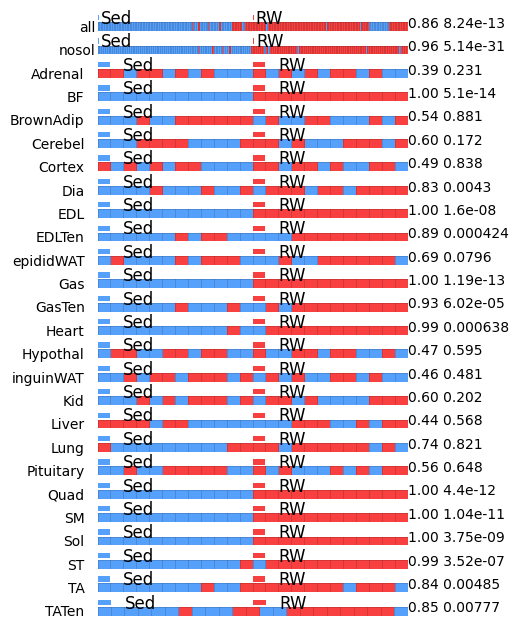

In [24]:
#test in all tissues
#test each individual muscle 

l1 = [set(up6).intersection(Egln3_mm), #could make this more strict later w upstrictdiffex
     set(up6).intersection(Cyfip2_mm),
     set(down6).intersection(Ppp1r1a_mm)]
l1_hs = [list(bone.getGroupsHs([l1[0]])[0]),list(bone.getGroupsHs([l1[1]])[0]),list(bone.getGroupsHs([l1[2]])[0])]
print(l1)
print(len(l1[0])+len(l1[1])+len(l1[2]))    
print(l1_hs) 
wt1 = [1,1,-1]

ana = bone.IBDAnalysis()
#ana.getPanda2024MuscleOnly()
ana.getPanda2024Exercise()
tissues = hu.uniq(ana.h.getSurvName("c Tissue")[2:])
fig,axes = bone.plt.subplots(ncols=1, nrows=len(tissues)+2, figsize=(4,8), dpi=100)
aucAvg = []
with HiddenPrints():
    ana = bone.IBDAnalysis()
    ana.getPanda2024MuscleOnly()
    ana.orderData(l1, wt1)
plotTitleBar(ana, axes[0], "all")
#with HiddenPrints(): #separate soleus, the stats didnt work correctly
#    ana = bone.IBDAnalysis()
#    ana.getPanda2024MuscleOnly(3)
#    ana.orderData(l1, wt1)
#plotTitleBar(ana, axes[1], "all")
with HiddenPrints():
    ana = bone.IBDAnalysis()
    ana.getPanda2024MuscleOnlynoSol()
    ana.orderData(l1, wt1)
plotTitleBar(ana, axes[1], "nosol")
ana.getPanda2024Exercise()
for ii in range(len(tissues)):
    ta = tissues[ii]
    #print(ta)
    with HiddenPrints():
        ana = bone.IBDAnalysis()
        ana.getPanda2024Exercise(2, ta)
        ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[ii+2], ta)
#print(aucAvg)
print('all:', sum(aucAvg)/len(aucAvg))
print('muscles:', sum(aucAvg[0:8])/len(aucAvg[0:8]))
print('sol:', aucAvg[7])

In [26]:
for i in l1:
    print(*i)

BC048679 Bdh1 Atf3 Fhl1 Egln3 Myh2 Fabp3 Slc26a10 Lmcd1 Myom3 Actn2 Vgll2 Ldhb Ankrd2 Hspb7 Casq2 Dusp18 Gm5532 Mb Csrp3 Fxyd6 Myh1 Ttc9
Ak4 H19
Pla2g5 Neu2 Fbp2 Fgfbp1 Gstm2


In [20]:
#[hu.uniq(dfup6['Name'][:15]), hu.uniq(dfdown6['Name'][-15:])]
print(hu.uniq(dfdown6['Name'][-15:]))

['Setd7', 'Ube2e1', 'Mylk2', 'Myo5c', 'Plaat1', 'Sh3bgr', 'Cacng1', 'Ubr1', 'Phkg1', 'Gpd1', 'Gm12224', 'Cnbp', 'Rab2a', 'Rbfox1', 'Prkab2']


/tmp/ipykernel_17090/3379044828.py:2: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  print(hu.uniq(dfdown6['Name'][-15:]))


In [10]:
#benchmark against top 30 genes (15 up 15 down) shared in all 6
thr = 0.01
ifile = "mf-results/muscleEx_ns-diff.txt"
#ifile = "results/panda24-exe-diff.txt"
high, low = bone.getFdrStats(ifile, thr, 0)
print (len(high), len(low))
df = pd.read_csv(ifile, sep="\t", header=None, names=["ID", "Name", "T", "P", "Diff"])
df = df[df['ID'].isin(high.union(low))].sort_values(by='T', ascending=False)
dfup6 = df[df["Name"].isin(up6)]
dfdown6 = df[df["Name"].isin(down6)]
df

4328 1941


,ID,Name,T,P,Diff
5520,ENSMUSG00000027984,Hadh,19.097332,1.421793e-43,0.315998
12730,ENSMUSG00000038302,Afg1l,19.075034,8.587566e-42,0.348452
12443,ENSMUSG00000019763,Rmnd1,18.555603,1.039970e-41,0.305701
16511,ENSMUSG00000032314,Etfa,17.742361,3.185020e-39,0.334463
22685,ENSMUSG00000046598,Bdh1,17.568499,7.829335e-37,1.666523
...,...,...,...,...,...
17854,ENSMUSG00000085888,Gm12224,-13.112481,1.046278e-25,-0.219411
9767,ENSMUSG00000030057,Cnbp,-13.207055,1.117915e-27,-0.171139
5766,ENSMUSG00000047187,Rab2a,-13.717496,9.941095e-29,-0.203825
22389,ENSMUSG00000008658,Rbfox1,-14.646023,1.079561e-31,-0.290457


In [15]:
benchmarkdiffexp = pd.concat([dfup6[:15],dfdown6[-15:]])
#benchmarkdiffexp
benchmarkdiffexp.to_csv("benckmarkDEGs.csv",index=None)

In [ ]:
hu.uniq(dfup6['Name'][:15])



+hu.uniq(dfdown6['Name'][-15:])

['Hadh',
 'Afg1l',
 'Rmnd1',
 'Etfa',
 'Bdh1',
 'Prdx2',
 'Hmgb3',
 'Ndufa10',
 'Atp5g3',
 'Mdh1',
 'Egln3',
 'Arl2bp',
 'Lpl',
 'Acadvl',
 'Hpdl',
 'Setd7',
 'Ube2e1',
 'Mylk2',
 'Myo5c',
 'Plaat1',
 'Sh3bgr',
 'Cacng1',
 'Ubr1',
 'Phkg1',
 'Gpd1',
 'Gm12224',
 'Cnbp',
 'Rab2a',
 'Rbfox1',
 'Prkab2']

4328 1941
panda-maier-MuscleNoSoleus-mouse-exercise-tpm-2023 (n = 168)
Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex3
168 [84, 84] Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex3 mmex3


/tmp/ipykernel_17090/88039851.py:16: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  wt1, l1 = [1, -1], [hu.uniq(dfup6['Name'][:15]), hu.uniq(dfdown6['Name'][-15:])]


[0.99, 0.56, 0.8, 0.68, 0.56, 0.58, 0.65, 0.44, 0.78]
0.6711111111111112
4328 1941
panda-maier-MuscleNoSoleus-mouse-exercise-tpm-2023 (n = 168)
Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex3
168 [84, 84] Panda Lab Geraldine Maier http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=mmex3 mmex3


/tmp/ipykernel_17090/88039851.py:122: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  wt1, l1 = [1, -1], [hu.uniq(dfup6['Name'][:22]), hu.uniq(dfdown6['Name'][-8:])]


[0.99, 0.6, 0.77, 0.69, 0.34, 0.53, 0.64, 0.93, 0.77]
0.6955555555555555


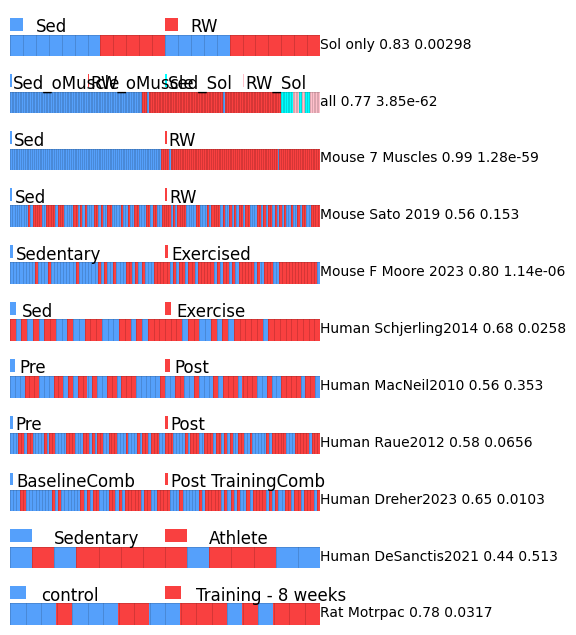

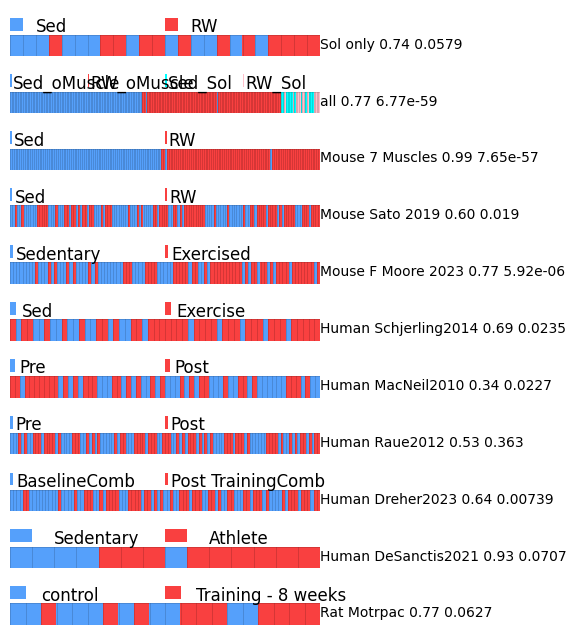

In [ ]:
#benchmark against top 30 genes (15 up 15 down) shared in all 6
thr = 0.01
ifile = "mf-results/muscleEx_ns-diff.txt"
#ifile = "results/panda24-exe-diff.txt"
high, low = bone.getFdrStats(ifile, thr, 0)
print (len(high), len(low))
df = pd.read_csv(ifile, sep="\t", header=None, names=["ID", "Name", "T", "P", "Diff"])
df = df[df['ID'].isin(high.union(low))].sort_values(by='T', ascending=False)
dfup6 = df[df["Name"].isin(up6)]
dfdown6 = df[df["Name"].isin(down6)]
#wt1, l1 = [0, 1], [high, low]
ana = bone.IBDAnalysis()
ana.getPanda2024MuscleOnlynoSol()

#wt1, l1 = [1, -1], [hu.uniq(dfup6['Name'][:22]), hu.uniq(dfdown6['Name'][-8:])]
wt1, l1 = [1, -1], [hu.uniq(dfup6['Name'][:15]), hu.uniq(dfdown6['Name'][-15:])]

fig,axes = bone.plt.subplots(ncols=1, nrows=11, figsize=(4,8), dpi=100)
aucAvg = []
with HiddenPrints():

    ana = bone.IBDAnalysis()
    ana.getPanda2024Exercise(2, "Sol")
    ana.orderData(l1, wt1)
    
    plotTitleBar(ana, axes[0], "Sol only")

    ana = bone.IBDAnalysis()
    ana.getPanda2024MuscleOnly(3)
    ana.orderData(l1, wt1)
    plotTitleBar(ana, axes[1], "all")
    
    ana = bone.IBDAnalysis()
    ana.getPanda2024MuscleOnlynoSol()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[2], "Mouse 7 Muscles")

    ana = bone.IBDAnalysis()
    ana.getSato2019()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[3], "Mouse Sato 2019")

    ana = bone.IBDAnalysis()
    ana.getmoore2023mouse()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[4], "Mouse F Moore 2023")

    ana = bone.IBDAnalysis()
    ana.getSchjerling2014()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[5], "Human Schjerling2014")



    ana = bone.IBDAnalysis()
    ana.getMacNeil2010()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[6], "Human MacNeil2010")

    ana = bone.IBDAnalysis()
    ana.getRaue2012()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[7], "Human Raue2012")


    ana = bone.IBDAnalysis()
    ana.getDreher2023AccuteLongTermVLat()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[8], "Human Dreher2023")

    ana = bone.IBDAnalysis()
    ana.getDeSanctis2021()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[9], "Human DeSanctis2021")

    ana = bone.IBDAnalysis()
    ana.getMotrpacVL(8)
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[10], "Rat Motrpac")
    '''
    ana = bone.IBDAnalysis()
    ana.getSchjerling2014EnduranceOnly()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[4], "Human Schjerling2014 Endurance")

    ana = bone.IBDAnalysis()
    ana.getSchjerling2014StrengthOnly()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[5], "Human Schjerling2014 Strength")
    '''
print(aucAvg)
print(sum(aucAvg)/len(aucAvg))
plt.savefig("ROC-AUC-BARS_all_degBenchmark_w_sol_1515.pdf", transparent=True, bbox_inches = 'tight')

#benchmark against top 30 genes (22 up 8 down) shared in all 6
thr = 0.01
ifile = "mf-results/muscleEx_ns-diff.txt"
#ifile = "results/panda24-exe-diff.txt"
high, low = bone.getFdrStats(ifile, thr, 0)
print (len(high), len(low))
df = pd.read_csv(ifile, sep="\t", header=None, names=["ID", "Name", "T", "P", "Diff"])
df = df[df['ID'].isin(high.union(low))].sort_values(by='T', ascending=False)
dfup6 = df[df["Name"].isin(up6)]
dfdown6 = df[df["Name"].isin(down6)]
#wt1, l1 = [0, 1], [high, low]
ana = bone.IBDAnalysis()
ana.getPanda2024MuscleOnlynoSol()


#wt1, l1 = [1, -1], [hu.uniq(dfup6['Name'][:32]), hu.uniq(dfdown6['Name'][-8:])]
wt1, l1 = [1, -1], [hu.uniq(dfup6['Name'][:22]), hu.uniq(dfdown6['Name'][-8:])]

fig,axes = bone.plt.subplots(ncols=1, nrows=11, figsize=(4,8), dpi=100)
aucAvg = []

with HiddenPrints():

    ana = bone.IBDAnalysis()
    ana.getPanda2024Exercise(2, "Sol")
    ana.orderData(l1, wt1)
    
    plotTitleBar(ana, axes[0], "Sol only")

    ana = bone.IBDAnalysis()
    ana.getPanda2024MuscleOnly(3)
    ana.orderData(l1, wt1)
    plotTitleBar(ana, axes[1], "all")
    
    ana = bone.IBDAnalysis()
    ana.getPanda2024MuscleOnlynoSol()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[2], "Mouse 7 Muscles")

    ana = bone.IBDAnalysis()
    ana.getSato2019()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[3], "Mouse Sato 2019")

    ana = bone.IBDAnalysis()
    ana.getmoore2023mouse()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[4], "Mouse F Moore 2023")

    ana = bone.IBDAnalysis()
    ana.getSchjerling2014()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[5], "Human Schjerling2014")

    ana = bone.IBDAnalysis()
    ana.getMacNeil2010()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[6], "Human MacNeil2010")

    ana = bone.IBDAnalysis()
    ana.getRaue2012()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[7], "Human Raue2012")


    ana = bone.IBDAnalysis()
    ana.getDreher2023AccuteLongTermVLat()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[8], "Human Dreher2023")

    ana = bone.IBDAnalysis()
    ana.getDeSanctis2021()
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[9], "Human DeSanctis2021")

    ana = bone.IBDAnalysis()
    ana.getMotrpacVL(8)
    ana.orderData(l1, wt1)
    aucAvg += [float(ana.getMetrics())]
    plotTitleBar(ana, axes[10], "Rat Motrpac")

print(aucAvg)
print(sum(aucAvg)/len(aucAvg))
plt.savefig("ROC-AUC-BARS_all_degBenchmark_w_sol_228.pdf", transparent=True, bbox_inches = 'tight')
